# II. Principal Component Analysis of TF-IDF Article Data

In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)

### 1. Principal Component Analysis

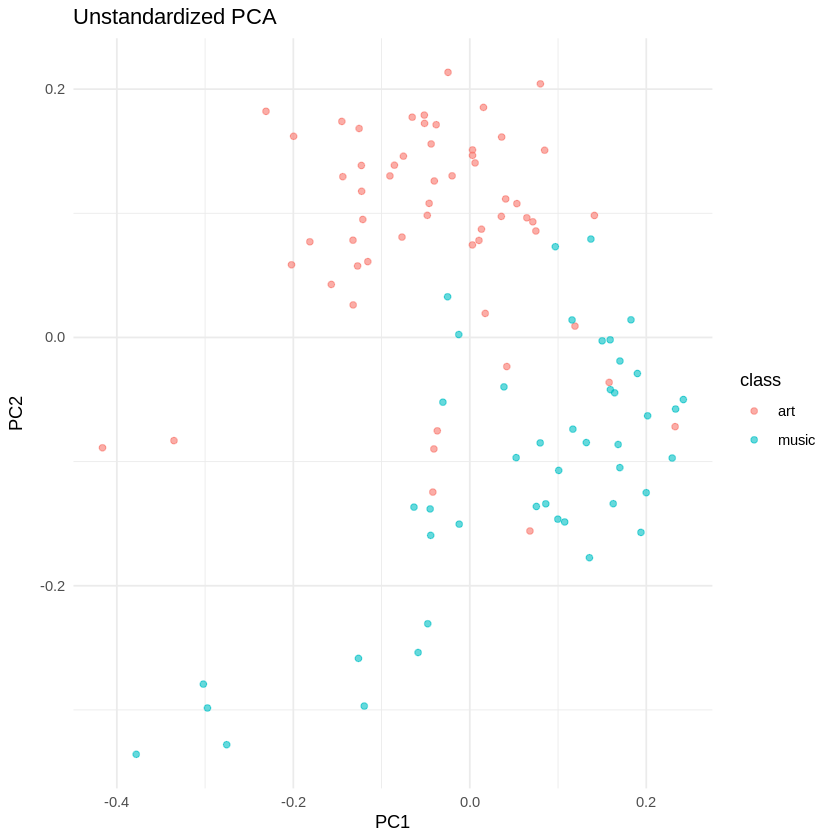

In [ ]:
df <- read.csv("nyt_articles-1.csv")

article_labels <- df$class.labels
X <- df[, sapply(df, is.numeric)]

X_cleaned <- X[, apply(X, 2, var) > 0]

pca_unstd <- prcomp(X_cleaned, scale = FALSE)

scores_unstd <- as.data.frame(pca_unstd$x)
scores_unstd$class <- article_labels

ggplot(scores_unstd, aes(x = PC1, y = PC2, color = class)) +
  geom_point(alpha = 0.6) +
  theme_minimal() +
  labs(title = "Unstandardized PCA", ,
       x = "PC1", y = "PC2")

### 2. Standardized vs. Unstandardized PCA

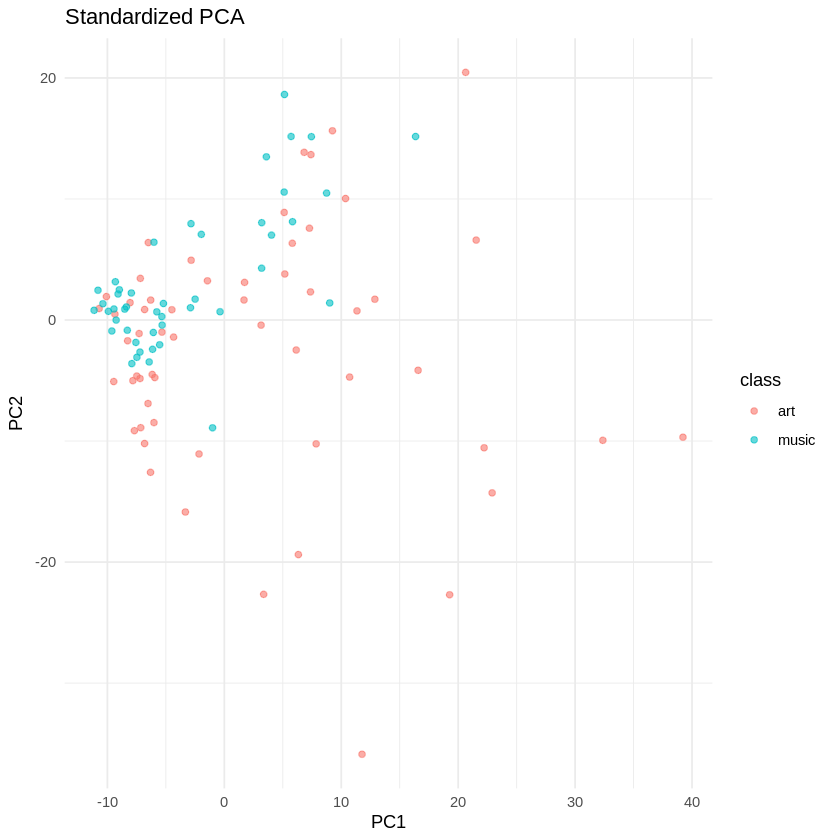

In [ ]:
pca_std <- prcomp(X_cleaned, scale = TRUE)

scores_std <- as.data.frame(pca_std$x)
scores_std$class <- article_labels

ggplot(scores_std, aes(x = PC1, y = PC2, color = class)) +
  geom_point(alpha = 0.6) +
  theme_minimal() +
  labs(title = "Standardized PCA",
       x = "PC1", y = "PC2")

1. Does PCA using standardized variables provide different insights from PCA using unstandardized variables?
   - Yes as the unstandardized articles are in two fairly distinct groups along the plot but in standardized the articles are all mixed together now, changing any insight to be gleamed entirely.
2. Which approach is more appropriate for this dataset?
   - The best approach would be to use the Unstandardized approach as the TF-IDF is instrically a weighted metric, meaning that standaradizing it only seeks to ruin the intentional weighing the dataset already provided.
3. What conclusions can be drawn about the articles?
   - The distinct groups between art and music in the Unstandardized approach showcases that art and music are mostly seperate and have mutually exclusive profiles

### 3. Biplot Interpretation

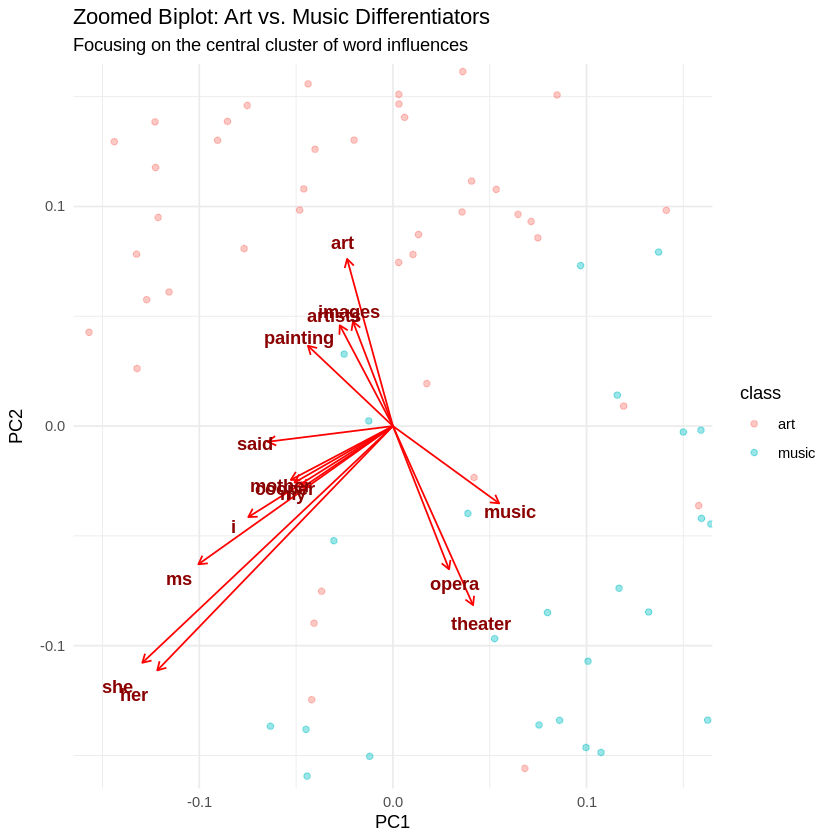

In [ ]:
loadings <- as.data.frame(pca_unstd$rotation[, 1:2])
loadings$word <- rownames(loadings)

top_vars <- loadings %>%
  mutate(total_load = abs(PC1) + abs(PC2)) %>%
  slice_max(total_load, n = 15)

scale_fact <- 0.4

zoom_limit <- 0.15

ggplot() +
  geom_point(data = scores_unstd, aes(x = PC1, y = PC2, color = class), alpha = 0.4) +
  geom_segment(data = top_vars, aes(x = 0, y = 0, xend = PC1 * 0.5, yend = PC2 * 0.5),
               arrow = arrow(length = unit(0.2, "cm")), color = "red") +
  geom_text(data = top_vars, aes(x = PC1 * 0.55, y = PC2 * 0.55, label = word),
            color = "darkred", fontface = "bold") +
  coord_cartesian(xlim = c(-zoom_limit, zoom_limit),
                  ylim = c(-zoom_limit, zoom_limit)) +
  theme_minimal() +
  labs(title = "Zoomed Biplot: Art vs. Music Differentiators",
       subtitle = "Focusing on the central cluster of word influences")

Interpretation:

Based on the axes the music related articles are at the bottom, such as opera and theater while the art related articles are at the top, such as painting and images.  Both of these groups of vectors are on essentially opposite ends of each other showing just how distinct each are.

Meanwhile a set of articles relating to neither art or music are so unrelated to both of these groups that they essentially form their own unique group